# QQQ Opening Range Bias — v2 (refactored engine + statistics)

Rewrite of `QQQ_bias.ipynb` on top of the parameterised engine in `src/backtest.py`.

**Fixes vs v1**
- one engine instead of three copy-pasted loops;
- the paper replication runs on **all complete QQQ sessions** (no longer conditioned on NQ data availability);
- incomplete sessions dropped as **whole days**, never as single bars;
- DST-safe NQ timestamp handling; commissions modelled ($0.0005/share/side).

**New analyses (roadmap items)**
- placebo test: QQQ's own 09:25 pre-market bar instead of NQ;
- per-trade t-stats and bootstrap CI on Sharpe;
- per-year PnL breakdown;
- PnL-vs-slippage sensitivity curve.

⚠️ Requires the two CSVs in `../data/` — see `data/README.md`.

In [60]:
import sys, datetime as dt
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import backtest as bt

CAPITAL = 25_000.0

## 1 · Data

QQQ drives the replication universe. NQ (and the day-intersection with QQQ) is used **only** by the filtered scenario, so the replication is no longer distorted by NQ data holes.

In [62]:
qqq = bt.load_qqq("../data/QQQ_5min_10years_UTC.csv")
nq = bt.load_nq("../data/nq-10y-1min.csv")

qqq_days = bt.complete_days(qqq)
nq_days = bt.complete_days(nq)
both_days = qqq_days & nq_days

qqq_full = bt.restrict_to_days(qqq, qqq_days)      # replication universe
qqq_both = bt.restrict_to_days(qqq, both_days)     # filtered-scenario universe
nq_both = bt.restrict_to_days(nq, both_days)

print(f"complete QQQ sessions: {len(qqq_days)}")
print(f"complete NQ sessions:  {len(nq_days)}")
print(f"intersection:          {len(both_days)}")

complete QQQ sessions: 1795
complete NQ sessions:  1780
intersection:          1780


## 2 · Scenarios

| # | universe | costs | confirmation |
|---|---|---|---|
| replication | all QQQ days | commission only | — |
| slippage | all QQQ days | + $0.02 entry / $0.04 stop | — |
| NQ filter | QQQ ∩ NQ days | + slippage | NQ 09:25 bar direction |
| placebo | all QQQ days | + slippage | QQQ **own** 09:25 pre-market bar |

The placebo is the control experiment: if it matches the NQ filter, the "cross-asset" story is really just pre-open momentum confirmation.

In [64]:
SLIP = dict(entry_slippage=0.02, stop_slippage=0.04)

nq_confirm = bt.bar_direction_by_day(nq_both, dt.time(9, 25))
qqq_confirm = bt.bar_direction_by_day(qqq_full, dt.time(9, 25))

trades = {
    "replication": bt.run_backtest(qqq_full),
    "slippage": bt.run_backtest(qqq_full, **SLIP),
    "nq_filter": bt.run_backtest(qqq_both, confirm_dir=nq_confirm, **SLIP),
    "placebo_qqq925": bt.run_backtest(qqq_full, confirm_dir=qqq_confirm, **SLIP),
}
pd.DataFrame({k: {"trades": len(v), "net_pnl": v["pnl"].sum().round(0),
                  "pnl_per_share": v["pnl_per_share"].mean().round(4)}
              for k, v in trades.items()}).T

,trades,net_pnl,pnl_per_share
replication,1775.0,138639.0,0.0704
slippage,1775.0,4860.0,0.0204
nq_filter,836.0,43246.0,0.1273
placebo_qqq925,825.0,25191.0,0.0787


## 3 · Risk-adjusted metrics vs buy & hold

In [66]:
def buy_hold_equity(df, capital=CAPITAL):
    px = df.groupby("day")["close"].last()
    eq = capital * px / px.iloc[0]
    eq.index = pd.to_datetime(eq.index)
    return eq

days_full = qqq_full["day"].unique()
equities = {k: bt.equity_curve(v, days_full if k != "nq_filter" else qqq_both["day"].unique())
            for k, v in trades.items()}
equities["buy_hold"] = buy_hold_equity(qqq_full)

metrics = pd.DataFrame({k: bt.compute_metrics(eq) for k, eq in equities.items()}).T
metrics.round(3)

,Sharpe,CAGR,MaxDD,Vol
replication,1.057,0.304,-0.224,0.290
slippage,0.233,0.027,-0.439,0.293
nq_filter,0.762,0.153,-0.311,0.220
placebo_qqq925,0.566,0.105,-0.272,0.216
buy_hold,0.724,0.153,-0.356,0.234


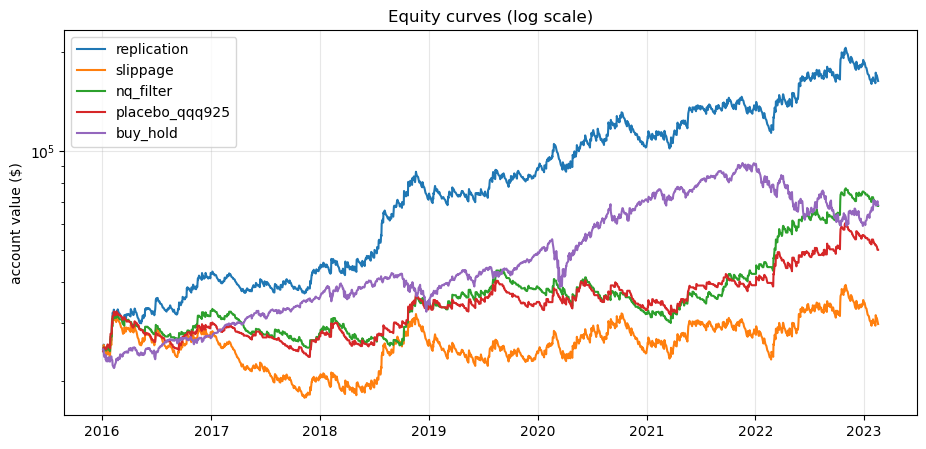

In [67]:
fig, ax = plt.subplots(figsize=(11, 5))
for k, eq in equities.items():
    ax.plot(eq.index, eq.values, label=k, lw=1.5)
ax.set_yscale("log"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Equity curves (log scale)"); ax.set_ylabel("account value ($)")
plt.show()

## 4 · Statistical significance

The question the v1 notebook never asked: **is the edge distinguishable from zero?**

In [69]:
pd.DataFrame({k: bt.trade_tstat(v) for k, v in trades.items()}).T.round(3)

,n,mean,t_stat
replication,1775.0,0.070,1.790
slippage,1775.0,0.020,0.516
nq_filter,836.0,0.127,2.065
placebo_qqq925,825.0,0.079,1.271


In [70]:
pd.DataFrame({k: bt.bootstrap_sharpe_ci(eq) for k, eq in equities.items()}).T.round(3)

,sharpe_lo,sharpe_hi,ci,n_boot
replication,0.344,1.713,0.95,5000.0
slippage,-0.535,0.930,0.95,5000.0
nq_filter,0.042,1.400,0.95,5000.0
placebo_qqq925,-0.174,1.206,0.95,5000.0
buy_hold,-0.025,1.466,0.95,5000.0


## 5 · Per-year breakdown

If the PnL concentrates in 2020–2022 (as published ORB results are known to), the edge is a volatility-regime artifact, not a structural one.

In [72]:
for k in ("replication", "nq_filter"):
    print(f"— {k}")
    display(bt.yearly_breakdown(trades[k]).round(3))

— replication


,trades,net_pnl,pnl_per_share,win_rate,avg_r
year,,,,,
2016,246,17701.751,0.067,0.264,0.415
2017,244,1737.366,0.015,0.234,-0.009
2018,248,26834.215,0.128,0.246,0.279
2019,251,17604.478,0.046,0.235,0.175
2020,250,14149.402,0.006,0.224,0.108
2021,252,31430.627,0.085,0.254,0.127
2022,251,53270.909,0.209,0.243,0.139
2023,33,-24089.305,-0.426,0.091,-0.476


— nq_filter


,trades,net_pnl,pnl_per_share,win_rate,avg_r
year,,,,,
2016,112,7743.410,0.091,0.277,0.326
2017,115,-4819.774,-0.035,0.217,-0.307
2018,119,5423.707,0.133,0.235,0.136
2019,116,5528.819,0.069,0.259,0.283
2020,116,-6816.005,-0.122,0.164,-0.235
2021,118,10355.478,0.224,0.297,0.250
2022,126,33045.363,0.582,0.310,0.505
2023,14,-7215.048,-0.653,0.071,-0.760


## 6 · Slippage sensitivity

Replaces the single $0.02 point estimate with the full curve: at what execution cost does the edge cross zero?

,entry_slippage,net_pnl,pnl_per_share,sharpe
0,0.000,138639.443,0.0704,1.0566
1,0.005,82012.710,0.0579,0.8490
2,0.010,44917.707,0.0454,0.6423
3,0.015,20709.038,0.0329,0.4373
4,0.020,4859.551,0.0204,0.2332
5,0.025,-5464.594,0.0079,0.0312
6,0.030,-12198.687,-0.0045,-0.1690
7,0.035,-16656.686,-0.0170,-0.3708
8,0.040,-19513.113,-0.0295,-0.5673
9,0.045,-21413.440,-0.0420,-0.7671


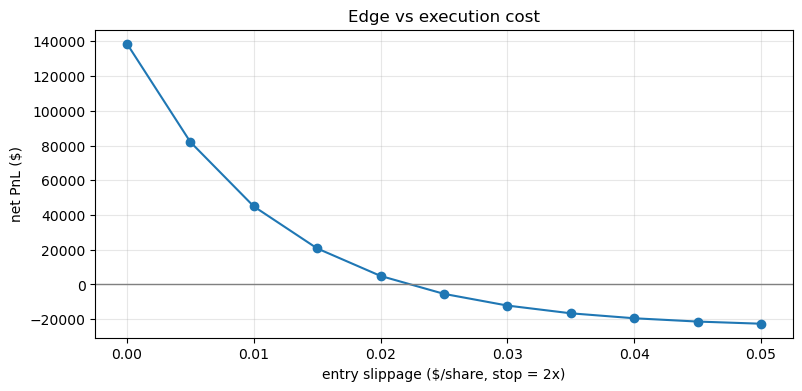

In [74]:
sens = bt.slippage_sensitivity(qqq_full, trading_days=days_full)
display(sens.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sens["entry_slippage"], sens["net_pnl"], marker="o")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("entry slippage ($/share, stop = 2x)"); ax.set_ylabel("net PnL ($)")
ax.set_title("Edge vs execution cost"); ax.grid(alpha=0.3)
plt.show()

## 7 · Exit-reason anatomy

The 10R target is quasi-decorative: most exits are EoD, i.e. the strategy is intraday momentum continuation with a 1R stop.

In [76]:
pd.DataFrame({k: v["reason"].value_counts(normalize=True).round(3) for k, v in trades.items()}).T

reason,stop,eod,target
replication,0.749,0.226,0.024
slippage,0.749,0.226,0.024
nq_filter,0.743,0.225,0.032
placebo_qqq925,0.752,0.219,0.029
